In [ ]:
!pip install -q torch torchtext datasets matplotlib

In [6]:
import os
import math
import re
import random
import unicodedata
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.utils.data import Dataset, DataLoader

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")

✅ Device: cuda


# Attention Mechanism

**The Information Bottleneck Problem**

A vanilla seq2seq encoder-decoder compresses the **entire** source sentence into
a single fixed-length vector (the encoder's final hidden state). The decoder must
then reconstruct the target sentence from this one vector alone.

```
Source: "El gato se sentó en la alfombra"
         ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
       [ Encoder RNN ────────→ ] → single vector h_T → [ Decoder RNN → ] → "The cat sat on the mat"
```

1. **Problem:** As source sentences grow longer, this single vector becomes a bottleneck — it cannot faithfully represent all the information the decoder needs.
2. Cho et al. (2014) showed that vanilla seq2seq performance degrades sharply on
sentences longer than ~20 tokens.

**The Attention Solution**

Instead of compressing into one vector, **let the decoder look back at all encoder states** and learn which ones are relevant at each decoding step.

```
Encoder states:   h_1   h_2   h_3   h_4   h_5   h_6   h_7
                   ↑     ↑     ↑↑    ↑     ↑     ↑     ↑
Attention weights: 0.05  0.05  0.70  0.05  0.05  0.05  0.05   ← learned per decoder step
                              ↓
                    Context vector c_t = weighted sum of h_i
                              ↓
                        Decoder step t → output token
```

At each decoder time step t, attention computes:
1. **Score** — how relevant is encoder state h_j to the current decoder state s_t?
2. **Normalize** — softmax over scores to get weights α_{t,j}
3. **Context** — weighted sum: c_t = Σ_j α_{t,j} · h_j


**Key difference:** Bahdanau uses the *previous* decoder state s_{t-1} (feeds context
into the current step), while Luong uses the *current* decoder state s_t (computes
context after the RNN step). This is a subtle but important architectural distinction.

# 1) Data Loading & Preprocessing

In [11]:
def unicode_to_ascii(s: str) -> str:
    """Strip non-ASCII diacritics (e.g., é → e)."""
    return "".join(
        c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn"
    )

def preprocess_sentence(w: str) -> str:
    """Normalize, tokenize punctuation, and wrap with start/end tokens."""
    w = unicode_to_ascii(w.lower().strip())
    # Space out punctuation so they become separate tokens
    w = re.sub(r"([?.!,¿])", r" \1 ", w)
    # Collapse multiple spaces
    w = re.sub(r"[\" \"]+", " ", w).strip()
    # Keep only letters and basic punctuation
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w).strip()
    return "<sos> " + w + " <eos>"

class Vocabulary:
    """Word-level vocabulary with <pad>, <unk>, <sos>, <eos> special tokens."""
    PAD_IDX = 0
    UNK_IDX = 1
    SOS_IDX = 2
    EOS_IDX = 3

    def __init__(self):
        self.word2idx = {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.word_count = Counter()

    def build(self, sentences: list, min_freq: int = 2):
        """Count words across all sentences and assign indices above min_freq."""
        for sent in sentences:
            self.word_count.update(sent.split())
        for word, count in self.word_count.most_common():
            if count >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, sentence: str, max_len: int) -> list:
        """Convert sentence string to list of integer indices, padded to max_len."""
        tokens = sentence.split()[:max_len]
        indices = [self.word2idx.get(w, self.UNK_IDX) for w in tokens]
        # Pad to max_len
        indices += [self.PAD_IDX] * (max_len - len(indices))
        return indices

    def decode(self, indices: list) -> list:
        """Convert list of integer indices back to word strings."""
        return [self.idx2word.get(i, "<unk>") for i in indices]

    def __len__(self):
        return len(self.word2idx)


# ── Dataset & DataLoader ──────────────────────────────────────────────────────

class TranslationDataset(Dataset):
    """Paired source-target sentence dataset with integer encoding."""

    def __init__(self, src_encoded: np.ndarray, tgt_encoded: np.ndarray):
        # src_encoded, tgt_encoded: (num_samples, max_len)
        self.src = torch.tensor(src_encoded, dtype=torch.long)
        self.tgt = torch.tensor(tgt_encoded, dtype=torch.long)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]


def load_and_prepare_data(
    filepath: str,
    num_examples: int = 20000,
    max_len: int = 15,
    min_freq: int = 2,
    batch_size: int = 64,
):
    """
    End-to-end data pipeline: load file → preprocess → build vocab → create DataLoader.

    Returns: train_loader, src_vocab, tgt_vocab, max_src_len, max_tgt_len
    """
    # Read tab-separated file: each line is "english\tspanish\t..."
    lines = open(filepath, encoding="UTF-8").read().strip().split("\n")

    src_sentences, tgt_sentences = [], []
    for line in lines[:num_examples]:
        parts = line.split("\t")
        tgt_raw = preprocess_sentence(parts[0])  # English (target)
        src_raw = preprocess_sentence(parts[1])  # Spanish (source)
        # Filter to short sentences for fast training
        if len(src_raw.split()) <= max_len and len(tgt_raw.split()) <= max_len:
            src_sentences.append(src_raw)
            tgt_sentences.append(tgt_raw)

    print(f"Sentence pairs after filtering: {len(src_sentences)}")

    # Build vocabularies
    src_vocab = Vocabulary()
    src_vocab.build(src_sentences, min_freq=min_freq)
    tgt_vocab = Vocabulary()
    tgt_vocab.build(tgt_sentences, min_freq=min_freq)
    print(f"Source vocab: {len(src_vocab)} | Target vocab: {len(tgt_vocab)}")

    # Determine max lengths from data
    max_src_len = max(len(s.split()) for s in src_sentences)
    max_tgt_len = max(len(s.split()) for s in tgt_sentences)

    # Encode all sentences to padded integer arrays
    # (num_samples, max_src_len) and (num_samples, max_tgt_len)
    src_encoded = np.array([src_vocab.encode(s, max_src_len) for s in src_sentences])
    tgt_encoded = np.array([tgt_vocab.encode(s, max_tgt_len) for s in tgt_sentences])

    dataset = TranslationDataset(src_encoded, tgt_encoded)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    return loader, src_vocab, tgt_vocab, max_src_len, max_tgt_len

In [12]:
# Spanish-English parallel corpus
if not os.path.exists("datasets/spa.txt"):
    os.makedirs("datasets", exist_ok=True)
    print("Downloading Spanish-English dataset...")
    os.system(
        "wget -q https://raw.githubusercontent.com/PacktPublishing/"
        "The-Deep-Learning-Challenge/master/Section%205/source/spa-eng/spa.txt "
        "-P datasets"
    )

train_loader, src_vocab, tgt_vocab, MAX_SRC_LEN, MAX_TGT_LEN = load_and_prepare_data(
    "datasets/spa.txt", num_examples=25000, max_len=15, batch_size=64
)

# Verify shapes from one batch
for src_batch, tgt_batch in train_loader:
    # src_batch: (batch_num, max_src_len), tgt_batch: (batch_num, max_tgt_len)
    print(f"Source batch: {src_batch.shape} | Target batch: {tgt_batch.shape}")
    break

Sentence pairs after filtering: 24999
Source vocab: 4298 | Target vocab: 2789
Source batch: torch.Size([64, 15]) | Target batch: torch.Size([64, 10])


# 2) RNN Attention

## 2.1 Encoder


1. Both Bahdanau and Luong attention operate over the same encoder output.
2. We use a bidirectional GRU so each encoder state captures both left and right context. The forward and backward hidden states are concatenated, giving encoder output dimension = 2 * hidden_dim.

In [15]:
class Encoder(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
        """
        Bidirectional GRU encoder.

        Args:
            vocab_size: source vocabulary size
            embed_dim: embedding dimension
            hidden_dim: GRU hidden dimension (output will be 2 * hidden_dim due to BiGRU)
            dropout: dropout rate on embeddings
        """
        super().__init__()
        self.hidden_dim = hidden_dim

        # Map token indices to dense vectors
        # (batch_num, src_len) → (batch_num, src_len, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=Vocabulary.PAD_IDX)
        self.dropout = nn.Dropout(dropout)

        # Bidirectional GRU: output dim = 2 * hidden_dim
        # (batch_num, src_len, embed_dim) → (batch_num, src_len, hidden_dim * 2)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Project concatenated bidirectional final states to decoder-compatible size
        # (batch_num, hidden_dim * 2) → (batch_num, hidden_dim)
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src: torch.Tensor):
        """
        Args:
            src: (batch_num, src_len) — source token indices
        Returns:
            outputs: (batch_num, src_len, hidden_dim * 2) — all encoder states
            hidden:  (batch_num, hidden_dim) — combined final state for decoder init
        """
        # (batch_num, src_len) → (batch_num, src_len, embed_dim)
        embedded = self.dropout(self.embedding(src))

        # (batch_num, src_len, embed_dim) → outputs: (batch_num, src_len, hidden_dim * 2)
        # hidden: (num_layers * 2, batch_num, hidden_dim)
        outputs, hidden = self.gru(embedded)

        # Concatenate forward and backward final hidden states
        # hidden[-2]: forward final, hidden[-1]: backward final
        # (batch_num, hidden_dim) + (batch_num, hidden_dim) → (batch_num, hidden_dim * 2)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)

        # Project to decoder hidden dimension
        # (batch_num, hidden_dim * 2) → (batch_num, hidden_dim)
        hidden = torch.tanh(self.fc_hidden(combined))

        return outputs, hidden

## 2.2 Shared Wrapper

In [22]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: nn.Module, device: torch.device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        src: torch.Tensor,
        tgt: torch.Tensor,
        teacher_forcing_ratio: float = 0.5,
    ) -> tuple:
        """
        Full seq2seq forward pass.

        Args:
            src: (batch_num, src_len) — source indices
            tgt: (batch_num, tgt_len) — target indices
            teacher_forcing_ratio: probability of using ground truth vs prediction

        Returns:
            all_logits:       (batch_num, tgt_len, vocab_size)
            all_attn_weights: (batch_num, tgt_len, src_len) — for visualization
        """
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        vocab_size = self.decoder.vocab_size

        # Run encoder
        # (batch_num, src_len) → outputs: (batch_num, src_len, encoder_dim), hidden: (batch_num, hidden_dim)
        encoder_outputs, hidden = self.encoder(src)

        # Storage for outputs
        all_logits = torch.zeros(batch_size, tgt_len, vocab_size, device=self.device)
        all_attn = torch.zeros(batch_size, tgt_len, src.size(1), device=self.device)

        # First decoder input is <sos>
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            # Single decoder step (works for both Bahdanau and Luong)
            logits, hidden, attn_w = self.decoder(input_token, hidden, encoder_outputs)
            all_logits[:, t, :] = logits
            all_attn[:, t, :] = attn_w

            # Teacher forcing decision
            use_teacher = random.random() < teacher_forcing_ratio
            # Greedy prediction: (batch_num, vocab_size) → (batch_num,)
            top1 = logits.argmax(1)
            input_token = tgt[:, t] if use_teacher else top1

        return all_logits, all_attn

In [24]:
def train_epoch(
    model: Seq2Seq,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    clip: float = 1.0,
) -> float:
    """Train for one epoch. Returns average loss."""
    model.train()
    epoch_loss = 0.0

    for src, tgt in loader:
        # (batch_num, src_len), (batch_num, tgt_len)
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        optimizer.zero_grad()

        # (batch_num, tgt_len, vocab_size), (batch_num, tgt_len, src_len)
        logits, _ = model(src, tgt, teacher_forcing_ratio=0.5)

        # Reshape for cross-entropy: skip first time step (it's the <sos> input)
        # (batch_num * (tgt_len - 1), vocab_size)
        logits_flat = logits[:, 1:].reshape(-1, logits.size(-1))
        # (batch_num * (tgt_len - 1),)
        targets_flat = tgt[:, 1:].reshape(-1)

        loss = criterion(logits_flat, targets_flat)
        loss.backward()

        # Gradient clipping prevents exploding gradients in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)

def translate_sentence(
    model: Seq2Seq,
    sentence: str,
    src_vocab: Vocabulary,
    tgt_vocab: Vocabulary,
    max_src_len: int,
    max_tgt_len: int,
) -> tuple:
    """
    Translate a single sentence using greedy decoding (no teacher forcing).

    Returns:
        predicted_words: list of output tokens
        attention_matrix: (tgt_len, src_len) numpy array for visualization
    """
    model.eval()
    with torch.no_grad():
        processed = preprocess_sentence(sentence)
        # (1, max_src_len)
        src_indices = torch.tensor(
            [src_vocab.encode(processed, max_src_len)], dtype=torch.long, device=DEVICE
        )

        # Encode
        encoder_outputs, hidden = model.encoder(src_indices)

        # Decode step by step
        input_token = torch.tensor([Vocabulary.SOS_IDX], device=DEVICE)
        predicted_words = []
        attn_matrix = []

        for _ in range(max_tgt_len):
            logits, hidden, attn_w = model.decoder(input_token, hidden, encoder_outputs)
            # (1, src_len) → (src_len,)
            attn_matrix.append(attn_w.squeeze(0).cpu().numpy())

            # Greedy: (1, vocab_size) → (1,)
            top1 = logits.argmax(1)
            token_idx = top1.item()

            if token_idx == Vocabulary.EOS_IDX:
                break

            predicted_words.append(tgt_vocab.idx2word.get(token_idx, "<unk>"))
            input_token = top1

    return predicted_words, np.array(attn_matrix)

In [25]:
def plot_attention(
    attention: np.ndarray,
    src_tokens: list,
    pred_tokens: list,
    title: str = "Attention Weights",
):
    """
    Plot attention heatmap.

    Args:
        attention: (tgt_steps, src_len) — attention weights matrix
        src_tokens: list of source word strings
        pred_tokens: list of predicted word strings
        title: plot title
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # attention: (tgt_steps, src_len)
    tgt_steps = min(len(pred_tokens), attention.shape[0])
    src_steps = min(len(src_tokens), attention.shape[1])
    attn_to_plot = attention[:tgt_steps, :src_steps]

    cax = ax.matshow(attn_to_plot, cmap="Blues", aspect="auto")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04, label="α weight")

    ax.set_xticks(range(src_steps))
    ax.set_xticklabels(src_tokens[:src_steps], rotation=45, ha="left", fontsize=9)
    ax.set_yticks(range(tgt_steps))
    ax.set_yticklabels(pred_tokens[:tgt_steps], fontsize=9)
    ax.set_xlabel("Source (Spanish)")
    ax.set_ylabel("Predicted (English)")
    ax.set_title(title, pad=20)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

## 2.2 Bahdanau Attention

**Scoring Function (Additive / Concat)**:
$$
score(s_{t-1}, h_j) = v^T · tanh(W_a · s_{t-1} + U_a · h_j)
$$

Where:
- `s_{t-1}` is the **previous** decoder hidden state (batch_num, hidden_dim)
- `h_j` is encoder state j (batch_num, src_len, encoder_dim)
- `W_a`, `U_a` are learned weight matrices
- `v` is a learned vector that projects to a scalar score

**Why "additive"?**

The decoder and encoder states are projected **separately** then added
inside tanh. This is more expressive than a simple dot product because the
two projections can learn independent transformations before combining.


**Architectural Detail**:

Bahdanau attention uses `s_{t-1}` (the state **before** the current GRU step).
The context vector is concatenated with the input embedding and fed **into**
the GRU. This means the decoder RNN already incorporates attention context
when computing its hidden state.

$$
[embed(y_{t-1}) ; context_t] → GRU → s_t → predict y_t
$$


![](https://www.tensorflow.org/images/seq2seq/attention_mechanism.jpg)


In [18]:
class BahdanauAttention(nn.Module):
    """
    Additive attention: score = v^T · tanh(W_a · s + U_a · h)

    Reference: Bahdanau et al., 2015 (Eq. 6 in the paper)
    """

    def __init__(self, encoder_dim: int, decoder_dim: int, attn_dim: int = 64):
        """
        Args:
            encoder_dim: dimension of encoder outputs (hidden_dim * 2 for BiGRU)
            decoder_dim: dimension of decoder hidden state
            attn_dim: intermediate projection dimension (controls capacity of alignment model)
        """
        super().__init__()

        # Project encoder states to attention space
        # (batch_num, src_len, encoder_dim) → (batch_num, src_len, attn_dim)
        self.W_a = nn.Linear(encoder_dim, attn_dim, bias=False)

        # Project decoder state to attention space
        # (batch_num, decoder_dim) → (batch_num, attn_dim)
        self.U_a = nn.Linear(decoder_dim, attn_dim, bias=False)

        # Collapse to scalar score per source position
        # (batch_num, src_len, attn_dim) → (batch_num, src_len, 1)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(
        self, decoder_hidden: torch.Tensor, encoder_outputs: torch.Tensor
    ) -> tuple:
        """
        Args:
            decoder_hidden:  (batch_num, decoder_dim) — s_{t-1}
            encoder_outputs: (batch_num, src_len, encoder_dim) — all h_j

        Returns:
            context: (batch_num, encoder_dim) — weighted sum of encoder states
            alpha:   (batch_num, src_len) — attention weights (for visualization)
        """
        # Project encoder outputs: each position independently
        # (batch_num, src_len, encoder_dim) → (batch_num, src_len, attn_dim)
        encoder_proj = self.W_a(encoder_outputs)

        # Project decoder state and broadcast across source positions
        # (batch_num, decoder_dim) → (batch_num, attn_dim) → (batch_num, 1, attn_dim)
        decoder_proj = self.U_a(decoder_hidden).unsqueeze(1)

        # Additive combination with tanh nonlinearity (Eq. 6 in Bahdanau et al.)
        # (batch_num, src_len, attn_dim) + (batch_num, 1, attn_dim) → (batch_num, src_len, attn_dim)
        energy = torch.tanh(encoder_proj + decoder_proj)

        # Reduce to scalar score per source position
        # (batch_num, src_len, attn_dim) → (batch_num, src_len, 1) → (batch_num, src_len)
        scores = self.v(energy).squeeze(-1)

        # Normalize to probability distribution over source positions
        # (batch_num, src_len) → (batch_num, src_len)
        alpha = F.softmax(scores, dim=1)

        # Weighted sum of encoder outputs (the "context vector")
        # Input: (batch_num, 1, src_len) × (batch_num, src_len, encoder_dim)
        # Output: (batch_num, 1, encoder_dim)
        context = torch.bmm(alpha.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, alpha

In [19]:
class BahdanauDecoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        encoder_dim: int,
        hidden_dim: int,
        attn_dim: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.attention = BahdanauAttention(encoder_dim, hidden_dim, attn_dim)

        # (batch_num, 1) → (batch_num, 1, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=Vocabulary.PAD_IDX)
        self.dropout = nn.Dropout(dropout)

        # GRU input = embedding + context vector
        # (batch_num, 1, embed_dim + encoder_dim) → (batch_num, 1, hidden_dim)
        self.gru = nn.GRU(embed_dim + encoder_dim, hidden_dim, batch_first=True)

        # Project decoder state to vocabulary logits
        # (batch_num, hidden_dim) → (batch_num, vocab_size)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(
        self,
        input_token: torch.Tensor,
        decoder_hidden: torch.Tensor,
        encoder_outputs: torch.Tensor,
    ) -> tuple:
        """
        Single decoder step.

        Args:
            input_token:     (batch_num,) — previous predicted or ground-truth token
            decoder_hidden:  (batch_num, hidden_dim) — s_{t-1}
            encoder_outputs: (batch_num, src_len, encoder_dim)

        Returns:
            logits:         (batch_num, vocab_size)
            decoder_hidden: (batch_num, hidden_dim) — s_t
            attn_weights:   (batch_num, src_len)
        """
        # Compute attention BEFORE the GRU step (using s_{t-1})
        # (batch_num, encoder_dim), (batch_num, src_len)
        context, attn_weights = self.attention(decoder_hidden, encoder_outputs)

        # Embed the input token
        # (batch_num,) → (batch_num, 1, embed_dim)
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))

        # Concatenate embedding with context vector
        # (batch_num, 1, embed_dim) + (batch_num, 1, encoder_dim) → (batch_num, 1, embed_dim + encoder_dim)
        gru_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)

        # GRU step: s_t = GRU([embed; context], s_{t-1})
        # (batch_num, 1, embed_dim + encoder_dim) → (batch_num, 1, hidden_dim)
        output, hidden = self.gru(gru_input, decoder_hidden.unsqueeze(0))

        # (1, batch_num, hidden_dim) → (batch_num, hidden_dim)
        hidden = hidden.squeeze(0)

        # Project to vocabulary distribution
        # (batch_num, hidden_dim) → (batch_num, vocab_size)
        logits = self.fc_out(hidden)

        return logits, hidden, attn_weights

In [27]:
EMBED_DIM = 128
HIDDEN_DIM = 256
ATTN_DIM = 64
EPOCHS = 3
LR = 1e-3

# Encoder dimension is 2 * hidden_dim due to bidirectional GRU
ENCODER_DIM = HIDDEN_DIM * 2

# Build Bahdanau model
bahdanau_encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
bahdanau_decoder = BahdanauDecoder(
    len(tgt_vocab), EMBED_DIM, ENCODER_DIM, HIDDEN_DIM, ATTN_DIM
).to(DEVICE)
bahdanau_model = Seq2Seq(bahdanau_encoder, bahdanau_decoder, DEVICE).to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in bahdanau_model.parameters() if p.requires_grad)
print(f"Bahdanau model parameters: {n_params:,}")

# Optimizer and loss (ignore padding in loss)
bahdanau_optimizer = optim.Adam(bahdanau_model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=Vocabulary.PAD_IDX)

# Training loop
bahdanau_losses = []
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(bahdanau_model, train_loader, bahdanau_optimizer, criterion)
    bahdanau_losses.append(loss)
    if epoch % 3 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{EPOCHS} — Loss: {loss:.4f}")

Bahdanau model parameters: 3,087,013
  Epoch  1/3 — Loss: 3.5777
  Epoch  3/3 — Loss: 1.8739


  SRC: hace mucho frio aqui .
  OUT: it s very cold .



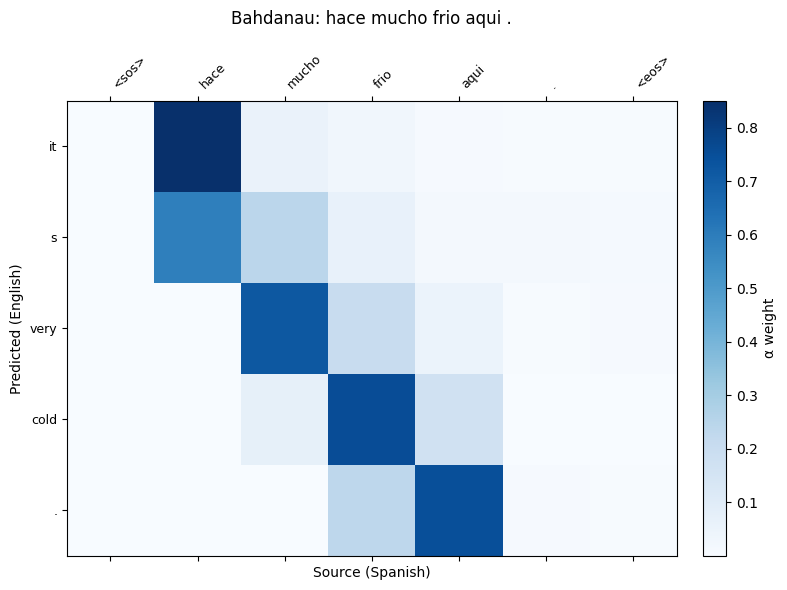

  SRC: esta es mi vida .
  OUT: this is my life .



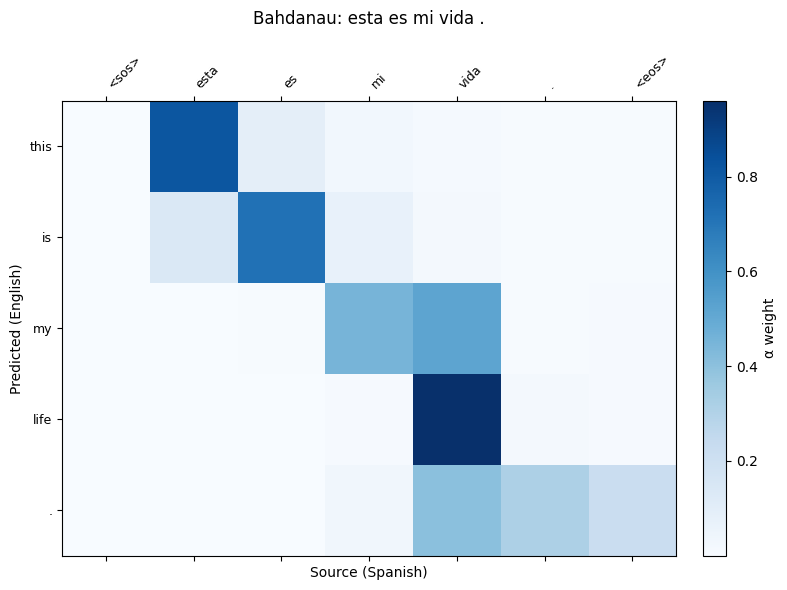

  SRC: ¿ todavia estan en casa ?
  OUT: are you in home ?



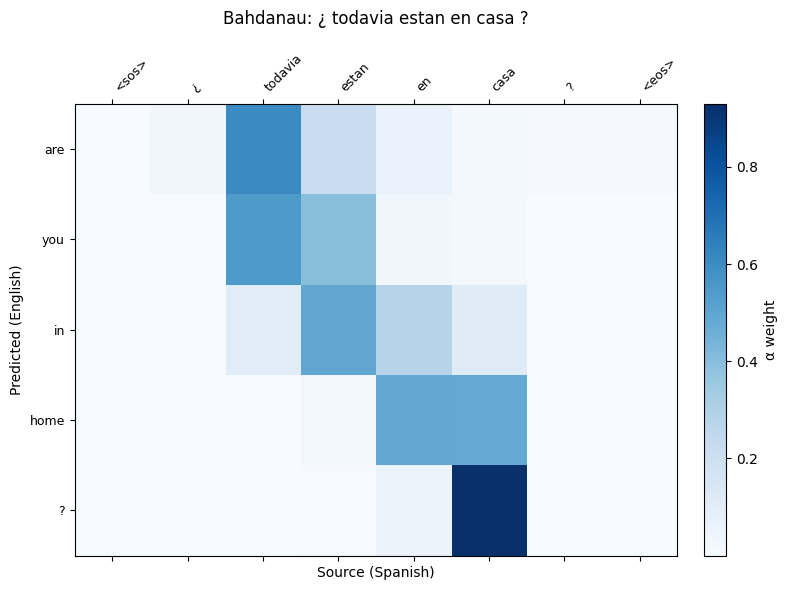

  SRC: tom no es viejo .
  OUT: tom isn t old .



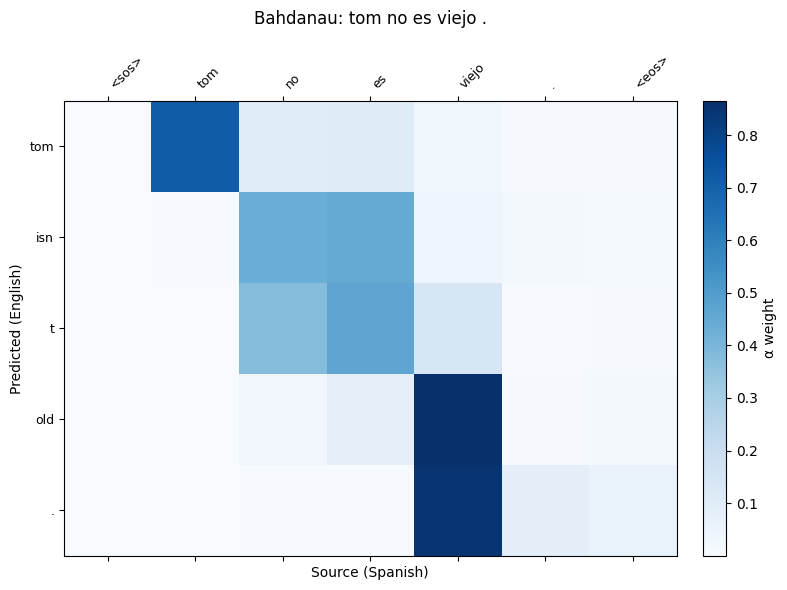

In [28]:
test_sentences = [
    "hace mucho frio aqui .",
    "esta es mi vida .",
    "¿ todavia estan en casa ?",
    "tom no es viejo .",
]

for sent in test_sentences:
    pred_words, attn_matrix = translate_sentence(
        bahdanau_model, sent, src_vocab, tgt_vocab, MAX_SRC_LEN, MAX_TGT_LEN
    )
    src_tokens = preprocess_sentence(sent).split()
    print(f"  SRC: {sent}")
    print(f"  OUT: {' '.join(pred_words)}\n")

    if len(pred_words) > 0 and attn_matrix.shape[0] > 0:
        plot_attention(attn_matrix, src_tokens, pred_words, title=f"Bahdanau: {sent}")

## 2.3 Luong Attention


**Scoring Functions (three variants)**:

| Variant  | Score Function              | Parameters       |
|----------|-----------------------------|------------------|
| dot      | s_t^T · h_j                | none             |
| general  | s_t^T · W_a · h_j          | W_a              |
| concat   | v^T · tanh(W_a·[s_t; h_j]) | W_a, v (≈ Bahdanau) |

We implement **general** as the default — it adds a learned bilinear transformation while remaining cheaper than the additive form.

**Key Architectural Difference from Bahdanau**
Luong attention uses the **current** decoder state s_t (computed first by the GRU), then computes the context and combines it with s_t to predict the output.

* If you had to translate a book's paragraph from French to English, you would not read the whole paragraph, then close the book and translate.
* Even during the translation process, you would read/re-read and focus on the parts of the French paragraph corresponding to the parts of the English you are writing down.
* The attention mechanism tells a Neural Machine Translation model where it should pay attention to at any step.

<table style="width:100%; border:none; border-collapse:collapse;">
  <tr>
    <td style="text-align:center; vertical-align:middle; border:none;">
      <img src="https://github.com/sebastianbirk/coursera-deep-learning-specialization/blob/master/05_sequence_models/06_neural_machine_translation_with_keras_lstm_attention/images/attn_model.png?raw=true" width="450" height="400">
    </td>
    <td style="text-align:center; vertical-align:middle; border:none;">
      <img src="https://raw.githubusercontent.com/sebastianbirk/coursera-deep-learning-specialization/refs/heads/master/05_sequence_models/06_neural_machine_translation_with_keras_lstm_attention/images/attn_mechanism.png" width="450" height="400">
    </td>
  </tr>
</table>
<caption><center> Figure 1: Neural machine translation with attention</center></caption>

In [29]:
class LuongAttention(nn.Module):
    """
    Multiplicative (general) attention: score = s_t^T · W_a · h_j

    Reference: Luong et al., 2015 (Eq. 8, "general" variant)
    """

    def __init__(self, encoder_dim: int, decoder_dim: int, method: str = "general"):
        """
        Args:
            encoder_dim: dimension of encoder outputs (hidden_dim * 2 for BiGRU)
            decoder_dim: dimension of decoder hidden state
            method: 'dot' or 'general' (default: 'general')
        """
        super().__init__()
        self.method = method

        if method == "general":
            # Learned bilinear projection: transforms encoder states before dot product
            # (batch_num, src_len, encoder_dim) → (batch_num, src_len, decoder_dim)
            self.W_a = nn.Linear(encoder_dim, decoder_dim, bias=False)
        elif method == "dot":
            # Dot product requires encoder_dim == decoder_dim
            assert encoder_dim == decoder_dim, (
                f"dot attention requires encoder_dim == decoder_dim, "
                f"got {encoder_dim} != {decoder_dim}"
            )

    def forward(
        self, decoder_hidden: torch.Tensor, encoder_outputs: torch.Tensor
    ) -> tuple:
        """
        Args:
            decoder_hidden:  (batch_num, decoder_dim) — s_t (current state)
            encoder_outputs: (batch_num, src_len, encoder_dim) — all h_j

        Returns:
            context: (batch_num, encoder_dim) — weighted sum of encoder states
            alpha:   (batch_num, src_len) — attention weights
        """
        if self.method == "general":
            # Project encoder states into decoder space
            # (batch_num, src_len, encoder_dim) → (batch_num, src_len, decoder_dim)
            projected = self.W_a(encoder_outputs)

            # Bilinear score: s_t^T · W_a · h_j via batched dot product
            # (batch_num, decoder_dim) → (batch_num, decoder_dim, 1)
            # (batch_num, src_len, decoder_dim) × (batch_num, decoder_dim, 1) → (batch_num, src_len, 1)
            scores = torch.bmm(projected, decoder_hidden.unsqueeze(2)).squeeze(2)
        else:
            # Simple dot product: s_t^T · h_j
            # (batch_num, src_len, encoder_dim) × (batch_num, encoder_dim, 1) → (batch_num, src_len)
            scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)

        # Normalize scores
        # (batch_num, src_len) → (batch_num, src_len)
        alpha = F.softmax(scores, dim=1)

        # Compute context vector
        # (batch_num, 1, src_len) × (batch_num, src_len, encoder_dim) → (batch_num, encoder_dim)
        context = torch.bmm(alpha.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, alpha

In [31]:
class LuongDecoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        encoder_dim: int,
        hidden_dim: int,
        method: str = "general",
        dropout: float = 0.1,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.attention = LuongAttention(encoder_dim, hidden_dim, method)

        # (batch_num, 1) → (batch_num, 1, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=Vocabulary.PAD_IDX)
        self.dropout = nn.Dropout(dropout)

        # GRU takes only the embedding (no context yet — that's the Luong distinction)
        # (batch_num, 1, embed_dim) → (batch_num, 1, hidden_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        # Attentional hidden state: combines s_t and context (Eq. 5 in Luong et al.)
        # (batch_num, hidden_dim + encoder_dim) → (batch_num, hidden_dim)
        self.W_c = nn.Linear(hidden_dim + encoder_dim, hidden_dim, bias=False)

        # Project attentional state to vocabulary logits
        # (batch_num, hidden_dim) → (batch_num, vocab_size)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(
        self,
        input_token: torch.Tensor,
        decoder_hidden: torch.Tensor,
        encoder_outputs: torch.Tensor,
    ) -> tuple:
        """
        Single decoder step (Luong-style: GRU first, then attend).

        Args:
            input_token:     (batch_num,) — previous token
            decoder_hidden:  (batch_num, hidden_dim) — s_{t-1}
            encoder_outputs: (batch_num, src_len, encoder_dim)

        Returns:
            logits:         (batch_num, vocab_size)
            decoder_hidden: (batch_num, hidden_dim) — s_t
            attn_weights:   (batch_num, src_len)
        """
        # Embed the input token
        # (batch_num,) → (batch_num, 1, embed_dim)
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))

        # GRU step FIRST — attention comes after (Luong's key design choice)
        # (batch_num, 1, embed_dim) → output: (batch_num, 1, hidden_dim)
        output, hidden = self.gru(embedded, decoder_hidden.unsqueeze(0))

        # (1, batch_num, hidden_dim) → (batch_num, hidden_dim)
        hidden = hidden.squeeze(0)

        # Now compute attention using the CURRENT state s_t
        # (batch_num, encoder_dim), (batch_num, src_len)
        context, attn_weights = self.attention(hidden, encoder_outputs)

        # Attentional hidden state: h_tilde = tanh(W_c · [s_t ; c_t])
        # (batch_num, hidden_dim + encoder_dim) → (batch_num, hidden_dim)
        h_tilde = torch.tanh(self.W_c(torch.cat([hidden, context], dim=1)))

        # Project to vocabulary
        # (batch_num, hidden_dim) → (batch_num, vocab_size)
        logits = self.fc_out(h_tilde)

        return logits, hidden, attn_weights

In [32]:
# Build Luong model (same encoder architecture, different decoder)
luong_encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
luong_decoder = LuongDecoder(
    len(tgt_vocab), EMBED_DIM, ENCODER_DIM, HIDDEN_DIM, method="general"
).to(DEVICE)
luong_model = Seq2Seq(luong_encoder, luong_decoder, DEVICE).to(DEVICE)

n_params = sum(p.numel() for p in luong_model.parameters() if p.requires_grad)
print(f"Luong model parameters: {n_params:,}")

luong_optimizer = optim.Adam(luong_model.parameters(), lr=LR)

# Training loop
EPOCHS = 3
luong_losses = []
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(luong_model, train_loader, luong_optimizer, criterion)
    luong_losses.append(loss)
    if epoch % 3 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{EPOCHS} — Loss: {loss:.4f}")

Luong model parameters: 2,972,261
  Epoch  1/3 — Loss: 3.5263
  Epoch  3/3 — Loss: 2.0068


  SRC: hace mucho frio aqui .
  OUT: it s a here here .



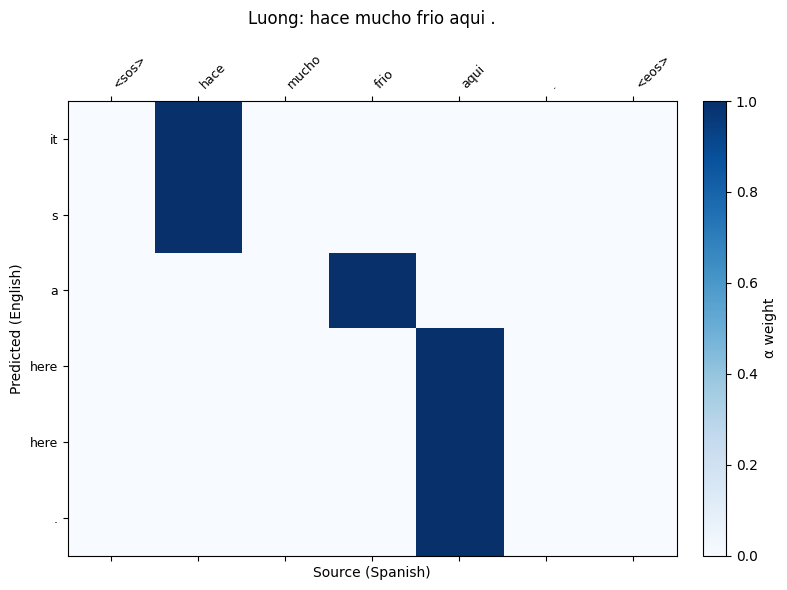

  SRC: esta es mi vida .
  OUT: this is my life .



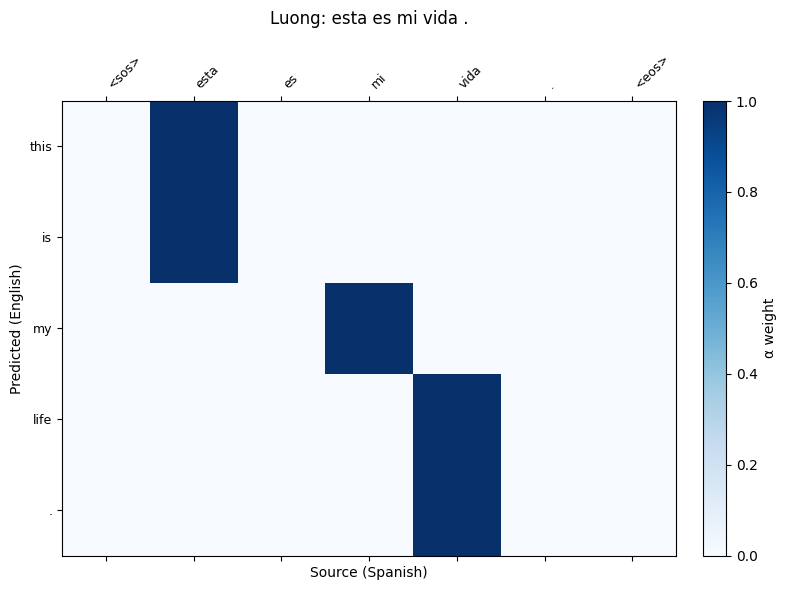

  SRC: ¿ todavia estan en casa ?
  OUT: are you home home ?



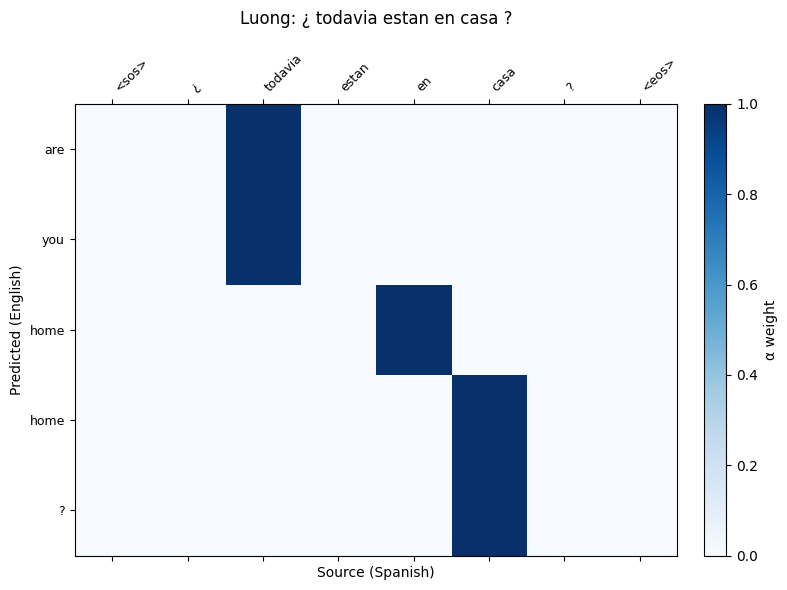

  SRC: tom no es viejo .
  OUT: tom isn t old .



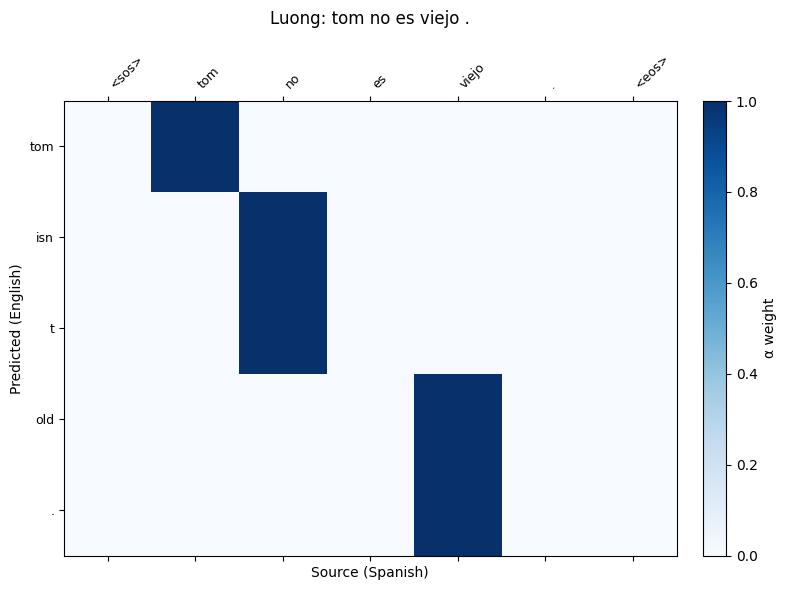

In [33]:
for sent in test_sentences:
    pred_words, attn_matrix = translate_sentence(
        luong_model, sent, src_vocab, tgt_vocab, MAX_SRC_LEN, MAX_TGT_LEN
    )
    src_tokens = preprocess_sentence(sent).split()
    print(f"  SRC: {sent}")
    print(f"  OUT: {' '.join(pred_words)}\n")

    if len(pred_words) > 0 and attn_matrix.shape[0] > 0:
        plot_attention(attn_matrix, src_tokens, pred_words, title=f"Luong: {sent}")

## 2.4 Comparison


## Key Observations to Look For:
1. **Convergence speed** — Luong (dot/general) is often slightly faster per step
   because its scoring function is cheaper than Bahdanau's two-layer MLP.
2. **Final loss** — Often comparable; Bahdanau's extra parameters may help on
   complex alignment tasks but rarely matter on short sentences.
3. **Attention patterns** — Bahdanau tends to produce sharper attention peaks
   (the additive MLP can learn more complex alignment functions); Luong's
   general attention can be smoother.

## Architectural Recap

| Aspect              | Bahdanau (2015)                | Luong (2015)                    |
|---------------------|--------------------------------|---------------------------------|
| Score function      | v^T·tanh(W·s + U·h) (additive)| s^T·W·h (bilinear/general)      |
| Decoder state used  | s_{t-1} (previous)             | s_t (current)                   |
| Context injection   | Before GRU (input feeding)     | After GRU (output combination)  |
| Complexity          | Higher (2 projections + tanh)  | Lower (1 projection)            |
| Expressiveness      | Can learn non-linear alignment | Linear alignment scoring        |

# 3) Scaled Dot-Product Attention

## 3.1 Self Attention

![](https://pbs.twimg.com/media/FzjhZk5X0AYAs_-?format=jpg&name=4096x4096)

In [ ]:
class Attention(nn.Module):
    def __init__(self, ori_dim:int=512, embed_dim:int=512) -> None:
        super().__init__()
        self.embed_dim = embed_dim
        self.dim_K = torch.tensor(embed_dim)

        # Linear layers to project input features to query, key, and value spaces
        # query/key/value: Input: (batch_num, seq_len, model_dim)
        # Output: (batch_num, seq_len, embed_dim)
        self.query = nn.Linear(in_features=ori_dim, out_features=embed_dim, bias=True)
        self.key   = nn.Linear(in_features=ori_dim, out_features=embed_dim, bias=True)
        self.value = nn.Linear(in_features=ori_dim, out_features=embed_dim, bias=True)

    def self_attention(self, Q:Tensor, K:Tensor, V:Tensor) -> Tensor:
        # Compute scaled dot-product attention scores and return weighted context vectors

        # Input Q, K, V: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim)

        # Transpose key for matrix multiplication
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, embed_dim, seq_len)
        K_T = torch.transpose(K, 1, 2)

        # Compute scaled similarity scores
        # Input: (batch_num, seq_len, embed_dim) x (batch_num, embed_dim, seq_len)
        # Output: (batch_num, seq_len, seq_len)
        score = torch.matmul(Q, K_T) / torch.sqrt(self.dim_K)

        # Apply softmax to normalize attention weights across key positions
        # Input: (batch_num, seq_len, seq_len) → Output: (batch_num, seq_len, seq_len)
        score = torch.softmax(score, dim=-1)

        # Compute weighted sum of values
        # Input: (batch_num, seq_len, seq_len) x (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim)
        Z = torch.matmul(score, V)
        return Z

    def forward(self, x:Tensor) -> Tensor:
        # Project input to Q, K, V then apply self-attention
        # Input: (batch_num, seq_len, model_dim)

        # Input: (batch_num, seq_len, model_dim) → Output: (batch_num, seq_len, embed_dim)
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Apply scaled dot-product attention
        # Input: Q/K/V=(batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        Z = self.self_attention(Q, K, V)
        return Z

## 3.2 Multi-head Attention

In [ ]:
class MultiheadAttention(nn.Module):
    """https://arxiv.org/abs/1706.03762"""

    def __init__(self, embed_dim:int=512, n_head:int=8) -> None:
        super().__init__()
        self.n_head = n_head
        self.embed_dim = embed_dim

        # Attention heads, each operating on a embed_dim // num_heads subspace
        # Each head: Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim // num_heads)
        self.multihead = nn.ModuleList([
            Attention(embed_dim, embed_dim // n_head) for _ in range(n_head)
        ])

    def forward(self, x: Tensor) -> Tensor:
        # Process input through num_heads attention heads and concatenate along feature dim
        # Input: (batch_num, seq_len, embed_dim)

        # Concatenate all head outputs along the last dimension
        # Input: num_heads * (batch_num, seq_len, embed_dim // num_heads)
        # Output: (batch_num, seq_len, embed_dim)
        Z = torch.cat([head(x) for head in self.multihead], dim=-1)
        return Z

In [ ]:
class MultiQueryAttention(nn.Module):
    """Multi-Query Attention (shared K/V across heads)"""

    def __init__(self, embed_dim: int = 512, n_head: int = 8) -> None:
        super().__init__()
        assert embed_dim % n_head == 0, "embed_dim must be divisible by n_head"

        self.n_head = n_head
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // n_head

        # Q projection: separate query for each head
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        self.q_proj = nn.Linear(embed_dim, embed_dim)

        # Shared K and V projections (single KV head, broadcast to all query heads)
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim // num_heads)
        self.k_proj = nn.Linear(embed_dim, self.head_dim)
        self.v_proj = nn.Linear(embed_dim, self.head_dim)

        # Final output projection
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x: Tensor) -> Tensor:
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim)
        batch_size, seq_len, _ = x.shape

        # Project and reshape query heads
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        Q = self.q_proj(x).view(batch_size, seq_len, self.n_head, self.head_dim).transpose(1, 2)

        # Shared K and V: project to single head then broadcast across all query heads
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, 1, seq_len, embed_dim // num_heads)
        K = self.k_proj(x).unsqueeze(1)
        V = self.v_proj(x).unsqueeze(1)

        # Compute scaled dot-product attention scores
        # Q=(batch_num, num_heads, seq_len, embed_dim // num_heads)
        # K=(batch_num, 1, seq_len, embed_dim // num_heads)
        # Output: (batch_num, num_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # Output: (batch_num, num_heads, seq_len, seq_len)
        attn = F.softmax(scores, dim=-1)

        # Compute weighted sum of shared values
        # Input: attn=(batch_num, num_heads, seq_len, seq_len)
        # Input: V=(batch_num, 1, seq_len, embed_dim // num_heads)
        # Output: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        Z = torch.matmul(attn, V)

        # Merge all heads back into full embedding dimension
        # Input: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        # Output: (batch_num, seq_len, embed_dim)
        Z = Z.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)

        # Final linear projection
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        Z = self.out_proj(Z)
        return Z

In [ ]:
class GroupedQueryAttention(nn.Module):
    """Grouped-Query Attention (shared K/V within groups)"""

    def __init__(self, embed_dim: int = 512, n_head: int = 8, n_kv_head: int = 4) -> None:
        super().__init__()
        assert embed_dim % n_head == 0, "embed_dim must be divisible by n_head"
        assert n_head % n_kv_head == 0, "n_head must be divisible by n_kv_head"

        self.n_head = n_head
        self.n_kv_head = n_kv_head
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // n_head
        self.n_query_each_group = n_head // n_kv_head

        # Q projection: one query vector per query head
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        self.q_proj = nn.Linear(embed_dim, embed_dim)

        # Group-shared K and V projections (one K/V vector per KV-head group)
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, n_kv_head * embed_dim // num_heads)
        self.k_proj = nn.Linear(embed_dim, n_kv_head * self.head_dim)
        self.v_proj = nn.Linear(embed_dim, n_kv_head * self.head_dim)

        # Final output projection
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x: Tensor) -> Tensor:
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim)
        batch_size, seq_len, _ = x.shape

        # Project and reshape query heads
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        Q = self.q_proj(x).view(batch_size, seq_len, self.n_head, self.head_dim).transpose(1, 2)

        # Project and reshape grouped K and V heads
        # Input: (batch_num, seq_len, embed_dim)
        # Output: (batch_num, n_kv_head, seq_len, embed_dim // num_heads)
        K = self.k_proj(x).view(batch_size, seq_len, self.n_kv_head, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.n_kv_head, self.head_dim).transpose(1, 2)

        # Expand grouped K/V so each query head shares the K/V from its group
        # Input: (batch_num, n_kv_head, seq_len, embed_dim // num_heads)
        # Output: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        K = K.repeat_interleave(self.n_query_each_group, dim=1)
        V = V.repeat_interleave(self.n_query_each_group, dim=1)

        # Compute scaled dot-product attention scores
        # Q=(batch_num, num_heads, seq_len, embed_dim // num_heads)
        # K=(batch_num, num_heads, seq_len, embed_dim // num_heads)
        # Output: (batch_num, num_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # Output: (batch_num, num_heads, seq_len, seq_len)
        attn = F.softmax(scores, dim=-1)

        # Compute weighted sum of values
        # attn=(batch_num, num_heads, seq_len, seq_len)
        # V=(batch_num, num_heads, seq_len, embed_dim // num_heads)
        # Output: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        Z = torch.matmul(attn, V)

        # Merge all heads back into full embedding dimension
        # Input: (batch_num, num_heads, seq_len, embed_dim // num_heads)
        # Output: (batch_num, seq_len, embed_dim)
        Z = Z.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)

        # Final linear projection
        # Input: (batch_num, seq_len, embed_dim) → Output: (batch_num, seq_len, embed_dim)
        Z = self.out_proj(Z)
        return Z

# 4) Attention Complexity and Efficiency Bottlenecks

- The standard scaled dot-product attention computes pairwise scores between all tokens in a sequence.
- This results in a time and memory complexity of $O(n^2d)$, where $n$ is the sequence length and $d$ is the head dimension.
- For long sequences (e.g., in long-context LLMs), the $n^2$ term dominates, leading to massive memory consumption.
- Furthermore, the true bottleneck on modern hardware (like GPUs) is often not compute, but memory bandwidth — moving the $n \times n$ attention matrix between High Bandwidth Memory (HBM) and the fast compute SRAM.

**Sample Input Output**
- Input: Sequence length $n=8192$, Head dimension $d=128$.
- Output: Attention matrix size $8192 \times 8192$ floats $\approx 268$ MB per head per layer.
- For a batch of 32 and 32 heads, this is over 274 GB of memory just to store intermediate attention scores for one layer.


To scale transformers to longer sequences, we must avoid materializing the full $O(n^2)$ attention matrix in HBM.

1. Techniques like Flash Attention restructure the computation to be IO-aware
2. While sparse attention patterns (like sliding windows) reduce the theoretical complexity from $O(n^2)$ to $O(n \times w)$, where $w$ is the window size.

## 4.1 Flash Attention

- Standard attention materializes the intermediate $Q K^T$ matrix to HBM to compute the softmax, then loads it back to multiply with $V$. This causes a memory bandwidth bottleneck.
- Flash Attention (Dao et al., 2022: *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*) avoids this by computing attention in blocks (tiling). It loads blocks of $Q$, $K$, and $V$ from HBM to SRAM, computes a running softmax, multiplies with $V$ in SRAM, and writes the final output back to HBM.

**Sample Input Output**
- Input: $Q$, $K$, $V$ tensors of shape `(batch_num, seq_len, embed_dim)`.
- Output: $Z$ tensor of shape `(batch_num, seq_len, embed_dim)`, mathematically equivalent to standard attention but computed block-wise.

- Flash Attention requires maintaining a running maximum and a running exponential sum to compute the softmax incrementally over tiles.
- The implementation below is a purely Python-based pedagogical simulation of the block-wise forward pass.
- While not actually faster without a custom CUDA kernel, it demonstrates the exact mathematics of tiling and the running softmax mechanism.

In [ ]:
def simulated_flash_attention_forward(Q: Tensor, K: Tensor, V: Tensor, block_size: int = 32):
    batch_num, seq_len, embed_dim = Q.shape

    # Initialize output tensor in HBM
    # (batch_num, seq_len, embed_dim)
    O = torch.zeros_like(Q)

    # Initialize running max and sum for softmax denominator
    # (batch_num, seq_len) -> (batch_num, seq_len, 1)
    m = torch.full((batch_num, seq_len, 1), float('-inf'), device=Q.device)
    l = torch.zeros((batch_num, seq_len, 1), device=Q.device)

    # Split tensors into blocks
    num_blocks = (seq_len + block_size - 1) // block_size

    for j in range(num_blocks):
        start_j = j * block_size
        end_j = min(start_j + block_size, seq_len)

        # Load block of K and V to SRAM
        # (batch_num, block_size, embed_dim)
        K_j = K[:, start_j:end_j, :]
        V_j = V[:, start_j:end_j, :]

        for i in range(num_blocks):
            start_i = i * block_size
            end_i = min(start_i + block_size, seq_len)

            # Load block of Q to SRAM
            # Input: (batch_num, seq_len, embed_dim)
            # Output: (batch_num, block_size, embed_dim)
            Q_i = Q[:, start_i:end_i, :]

            # Compute block dot product
            # Input: (batch_num, block_size, embed_dim) x (batch_num, embed_dim, block_size)
            # Output: (batch_num, block_size, block_size)
            S_ij = torch.bmm(Q_i, K_j.transpose(1, 2)) / math.sqrt(embed_dim)

            # Load previous running statistics
            # (batch_num, seq_len, 1) -> (batch_num, block_size, 1)
            m_i = m[:, start_i:end_i, :]
            l_i = l[:, start_i:end_i, :]

            # Compute new running max
            # Input: (batch_num, block_size, block_size)
            # Output: (batch_num, block_size, 1)
            m_ij = torch.max(S_ij, dim=-1, keepdim=True).values
            m_new = torch.maximum(m_i, m_ij)

            # Compute exponentiated scores stabilized by the new max
            # Input: (batch_num, block_size, block_size)
            # Output: (batch_num, block_size, block_size)
            P_ij = torch.exp(S_ij - m_new)

            # Update running sum
            # (batch_num, block_size, 1)
            l_new = torch.exp(m_i - m_new) * l_i + torch.sum(P_ij, dim=-1, keepdim=True)

            # Load previous output block
            # Input: (batch_num, seq_len, embed_dim)
            # Output: (batch_num, block_size, embed_dim)
            O_i = O[:, start_i:end_i, :]

            # Update output block
            # Input: (batch_num, block_size, embed_dim)
            # Output: (batch_num, block_size, embed_dim)
            O_new = (torch.exp(m_i - m_new) * O_i + torch.bmm(P_ij, V_j))

            # Write updated blocks back to HBM
            O[:, start_i:end_i, :] = O_new
            m[:, start_i:end_i, :] = m_new
            l[:, start_i:end_i, :] = l_new

    # Final normalization step
    # Input (batch_num, seq_len, embed_dim) / (batch_num, seq_len, 1)
    # Output: (batch_num, seq_len, embed_dim)
    O = O / l

    return O

# Test the simulated Flash Attention
Q = torch.randn(2, 64, 128)
K = torch.randn(2, 64, 128)
V = torch.randn(2, 64, 128)

out_flash = simulated_flash_attention_forward(Q, K, V, block_size=16)

# Verify correctness against standard attention
S = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(128)
P = torch.softmax(S, dim=-1)
out_std = torch.bmm(P, V)

print(
    "Max difference between standard and simulated Flash Attention:",
    torch.max(torch.abs(out_flash - out_std)).item()
)


## 4.2 Sliding Window and Sparse Attention

1. Not all tasks require global attention. In many sequences, local context is sufficient for token representations.
2. Sliding window attention restricts the receptive field of each query to a fixed neighborhood of surrounding keys, reducing complexity from $O(n^2)$ to $O(n \times w)$ where $w$ is the window size.
3. This was popularized by models like Longformer (Beltagy et al., 2020) and Sparse Transformers (Child et al., 2019).
4. We create a banded matrix mask based on the distance between query index $i$ and key index $j$. If $|i - j| > \text{window\_size} // 2$, we apply a large negative value to the attention score before softmax, effectively pruning those connections.
5. While this dense implementation still creates an $n \times n$ matrix in PyTorch (for educational clarity), optimized kernels (like BlockSparse) only compute the non-zero blocks.

**Sample Input Output**
- Input: Sequence length $n=10$, Window size $w=3$ (1 token left, 1 token right, plus itself).
- Output: An attention mask where only a narrow diagonal band is True (allowed), and the rest is False (-inf mask).

In [ ]:
class SlidingWindowAttention(nn.Module):
    def __init__(self, embed_dim: int, window_size: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.window_size = window_size
        self.scale = math.sqrt(embed_dim)

        # Linear projections for query, key, value
        # (batch_num, seq_len, embed_dim) -> (batch_num, seq_len, embed_dim)
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x: Tensor) -> Tensor:
        batch_num, seq_len, embed_dim = x.shape

        # Project inputs
        # (batch_num, seq_len, embed_dim) -> (batch_num, seq_len, embed_dim)
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Compute dense scaled dot-product scores
        # Input: (batch_num, seq_len, embed_dim) x (batch_num, embed_dim, seq_len)
        # Output: (batch_num, seq_len, seq_len)
        scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale

        # Generate sliding window mask
        # (seq_len, 1) - (1, seq_len) -> (seq_len, seq_len)
        idx = torch.arange(seq_len, device=x.device)
        distance = torch.abs(idx.unsqueeze(1) - idx.unsqueeze(0))

        # Create boolean mask where True means to drop the score
        # (seq_len, seq_len) -> (seq_len, seq_len)
        mask = distance > (self.window_size // 2)

        # Apply mask by setting outside-window elements to -infinity
        # (batch_num, seq_len, seq_len) -> (batch_num, seq_len, seq_len)
        scores = scores.masked_fill(mask.unsqueeze(0), float('-inf'))

        # Compute attention probabilities
        # (batch_num, seq_len, seq_len) -> (batch_num, seq_len, seq_len)
        attn_weights = F.softmax(scores, dim=-1)

        # Multiply by values to get context
        # Input (batch_num, seq_len, seq_len) x (batch_num, seq_len, embed_dim)
        # Output: (batch_num, seq_len, embed_dim)
        output = torch.bmm(attn_weights, V)

        return output

# Demonstrate Sliding Window Attention
x = torch.randn(1, 10, 64)
window_attn = SlidingWindowAttention(embed_dim=64, window_size=3)
out_sparse = window_attn(x)

print("Output shape of Sliding Window Attention:", out_sparse.shape)